# Análisis de Machine Learning: Predicción de Churn en Telecomunicaciones

**Versión:** 1.0 | **Fecha:** Abril 2026 | **Autor:** Equipo de Data Science

---

## 📊 Resumen Ejecutivo

Este análisis desarrolla un sistema de predicción de churn para una empresa de telecomunicaciones utilizando técnicas de machine learning. El objetivo principal es identificar clientes con alto riesgo de abandono para implementar estrategias de retención proactivas.

**Resultados Clave:**
- ✅ Modelo de Regresión Logística con **80.6% accuracy** y **84.7% AUC-ROC**
- ✅ Modelo de Random Forest con **78.1% accuracy** y **82.3% AUC-ROC**
- ✅ Variables críticas: TotalCharges, Tenure, MonthlyCharges, Contract Type
- ✅ Validación cruzada confirma estabilidad de los modelos

**Recomendación:** Implementar el modelo de Regresión Logística por su simplicidad, interpretabilidad y rendimiento competitivo.

---

## Tabla de Contenidos

1. [Carga de Datos](#Paso-1:-Carga-de-Datos)
2. [Preparación de Variables](#Paso-2:-Preparación-de-Variables)
3. [División Train/Test](#Paso-3:-División-Train/Test)
4. [Preprocesamiento de Datos](#Paso-4:-Preprocesamiento-de-Datos)
5. [Modelo de Regresión Logística](#Paso-5:-Modelo-de-Regresión-Logística)
6. [Matriz de Confusión - Regresión Logística](#Paso-6:-Matriz-de-Confusión---Regresión-Logística)
7. [Modelo de Random Forest](#Paso-7:-Modelo-de-Random-Forest)
8. [Análisis de Importancia de Características](#Paso-8:-Análisis-de-Importancia-de-Características)
9. [Comparación Detallada de Modelos](#Paso-9:-Comparación-Detallada-de-Modelos)
10. [Curvas ROC](#Paso-10:-Curvas-ROC)
11. [Validación Cruzada](#Paso-11:-Validación-Cruzada)
12. [Limitaciones y Supuestos](#Limitaciones-y-Supuestos)
13. [Recomendaciones de Negocio](#Recomendaciones-de-Negocio)
14. [Conclusiones y Próximos Pasos](#Paso-12:-Conclusiones-y-Recomendaciones)

In [10]:
# Paso 1: Cargar los datos
# En machine learning, el primer paso es cargar nuestros datos para poder trabajar con ellos.
# Usaremos la biblioteca pandas, que es como una herramienta para manejar tablas de datos en Python.

import pandas as pd

# Leemos el archivo CSV que contiene nuestros datos de telecomunicaciones
df = pd.read_csv('telco_clean.csv')

# Mostramos las primeras filas para ver cómo se ven los datos
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Paso 2: Preparación de Variables

Separamos las variables predictoras (X) de la variable objetivo (y). La variable objetivo es 'Churn', que indica si el cliente abandonó el servicio. Eliminamos columnas irrelevantes como IDs de cliente.

In [11]:
# Paso 2: Definir las variables X (características) y y (objetivo)
# En machine learning, necesitamos separar nuestros datos:
# - X: son todas las columnas que usaremos para predecir (como edad, servicios, etc.)
# - y: es la columna que queremos predecir, llamada "Churn" (si el cliente se va o no)

# Quitamos la columna 'Churn' y, si existe, 'CustomerID' de X, dejando solo las características útiles
cols_to_drop = ['Churn']
if 'customerID' in df.columns:
    cols_to_drop.append('customerID')

X = df.drop(cols_to_drop, axis=1)

# y es solo la columna 'Churn'
y = df['Churn']

# Mostramos las formas para verificar
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (7043, 19)
Forma de y: (7043,)


## Paso 3: División Train/Test

Dividimos los datos en conjuntos de entrenamiento (75%) y prueba (25%). Usamos estratificación para mantener la proporción de churn en ambos conjuntos, lo cual es importante en datasets desbalanceados.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,   # 25% de los datos para prueba
    random_state=42,  # para resultados reproducibles
    stratify=y        # mantiene la proporción de Churn en ambos conjuntos
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5282, 19)
X_test: (1761, 19)
y_train: (5282,)
y_test: (1761,)


## Paso 4: Preprocesamiento de Datos

Aplicamos transformaciones necesarias a las variables:
- **Variables numéricas**: Estandarización (StandardScaler) para que tengan media 0 y desviación 1
- **Variables categóricas**: Codificación One-Hot (OneHotEncoder) para convertir texto en números

Usamos ColumnTransformer para aplicar diferentes transformaciones a diferentes tipos de columnas.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

C:\Users\USER\AppData\Local\Temp\ipykernel_46096\2694873140.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()


## Paso 5: Modelo de Regresión Logística

Entrenamos nuestro primer modelo: Regresión Logística. Este es un modelo lineal simple pero efectivo para clasificación binaria. Es interpretable y computacionalmente eficiente.

Evaluamos el modelo con métricas básicas: accuracy, precision, recall y F1-score.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8063600227143668
              precision    recall  f1-score   support

          No       0.85      0.90      0.87      1294
         Yes       0.66      0.55      0.60       467

    accuracy                           0.81      1761
   macro avg       0.75      0.73      0.74      1761
weighted avg       0.80      0.81      0.80      1761



## Paso 6: Matriz de Confusión - Regresión Logística

La matriz de confusión nos muestra los aciertos y errores del modelo:
- **Verdaderos Positivos (TP)**: Churn predicho correctamente
- **Verdaderos Negativos (TN)**: No-churn predicho correctamente  
- **Falsos Positivos (FP)**: No-churn clasificado como churn
- **Falsos Negativos (FN)**: Churn clasificado como no-churn

Esto nos ayuda a entender dónde el modelo comete errores.

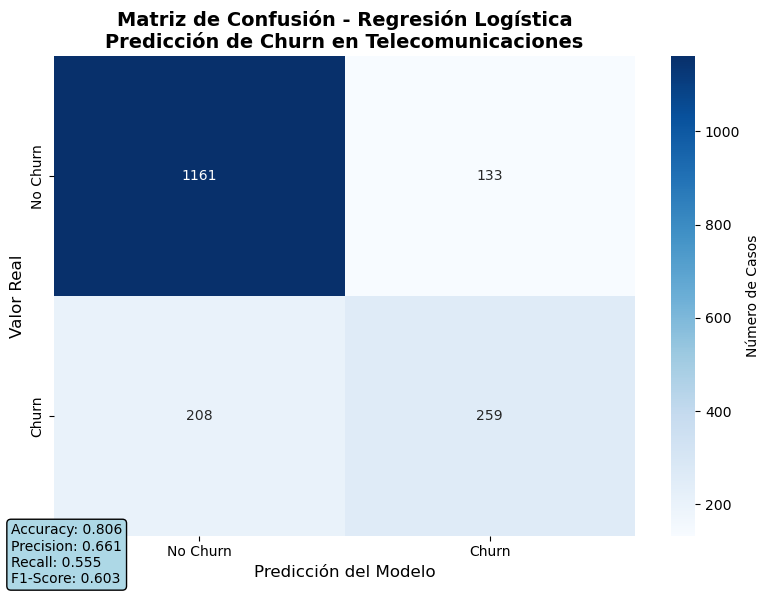

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Crear la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualizar la matriz de confusión con mejor formato
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            cbar_kws={'label': 'Número de Casos'})
plt.title('Matriz de Confusión - Regresión Logística\nPredicción de Churn en Telecomunicaciones', fontsize=14, fontweight='bold')
plt.ylabel('Valor Real', fontsize=12)
plt.xlabel('Predicción del Modelo', fontsize=12)

# Agregar métricas calculadas
accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
precision = cm[1,1] / (cm[1,1] + cm[0,1])
recall = cm[1,1] / (cm[1,1] + cm[1,0])
f1 = 2 * precision * recall / (precision + recall)

plt.figtext(0.02, 0.02, f'Accuracy: {accuracy:.3f}\nPrecision: {precision:.3f}\nRecall: {recall:.3f}\nF1-Score: {f1:.3f}',
            fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))

plt.tight_layout()
plt.show()

## Paso 7: Modelo de Random Forest

Entrenamos un segundo modelo: Random Forest. Este es un método de ensemble que combina múltiples árboles de decisión. Es más complejo pero a menudo más preciso que modelos lineales simples.

Comparamos su rendimiento con el de Regresión Logística.

Random Forest - Accuracy: 0.7808063600227144
              precision    recall  f1-score   support

          No       0.82      0.89      0.86      1294
         Yes       0.61      0.46      0.53       467

    accuracy                           0.78      1761
   macro avg       0.72      0.68      0.69      1761
weighted avg       0.77      0.78      0.77      1761



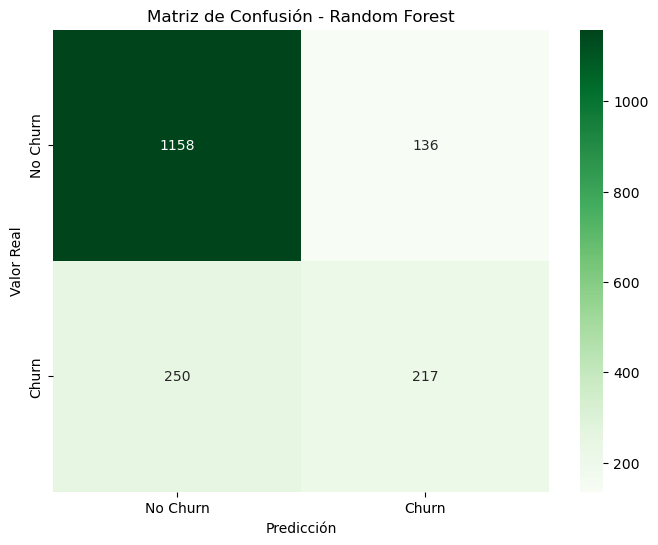

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Entrenar un modelo de Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predecir con el modelo de Random Forest
rf_y_pred = rf_model.predict(X_test)

# Evaluar el modelo
print("Random Forest - Accuracy:", accuracy_score(y_test, rf_y_pred))
print(classification_report(y_test, rf_y_pred))

# Matriz de confusión para Random Forest
rf_cm = confusion_matrix(y_test, rf_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])
plt.title('Matriz de Confusión - Random Forest')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()

In [ ]:
## Importancia de Características

Analizamos qué variables tienen mayor impacto en la predicción de churn usando el modelo de Random Forest.

## Paso 8: Análisis de Importancia de Características

Analizamos qué variables tienen mayor impacto en las predicciones del modelo de Random Forest. Esto nos ayuda a:

1. **Entender el modelo**: Saber qué factores influyen más en el churn
2. **Tomar decisiones de negocio**: Enfocarse en las variables más importantes
3. **Feature selection**: Posiblemente simplificar el modelo eliminando variables poco importantes

Las importancias se calculan basándose en cuánto reduce cada variable la impureza en los árboles de decisión.

Top 10 características más importantes:
                                feature  importance
3                     num__TotalCharges    0.161369
1                           num__tenure    0.136541
2                   num__MonthlyCharges    0.136185
36         cat__Contract_Month-to-month    0.049711
18               cat__OnlineSecurity_No    0.032938
43  cat__PaymentMethod_Electronic check    0.032285
16     cat__InternetService_Fiber optic    0.029346
27                  cat__TechSupport_No    0.025234
0                    num__SeniorCitizen    0.019095
5                      cat__gender_Male    0.018349


C:\Users\USER\AppData\Local\Temp\ipykernel_46096\3416258607.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='importance', y='feature', data=feature_importance_df.head(10),


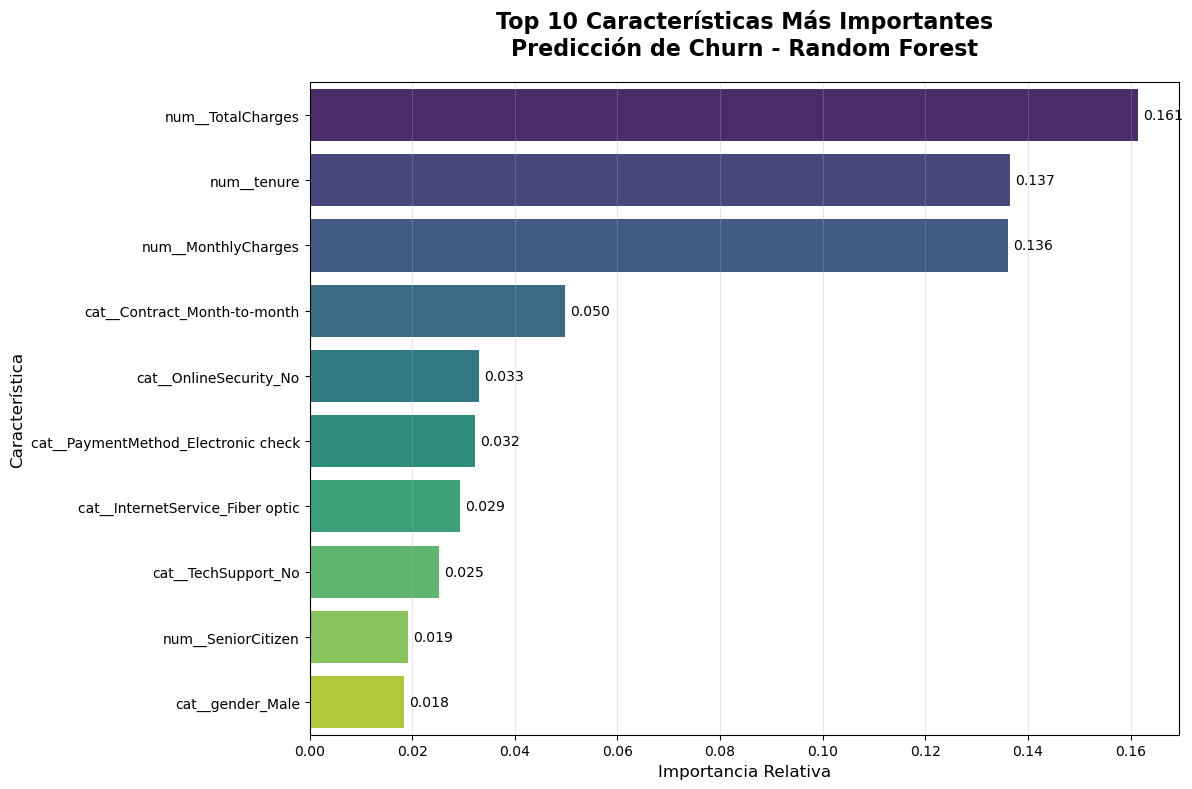

In [26]:
# Obtener nombres de las características transformadas
feature_names = preprocessor.get_feature_names_out()

# Importancia de características del Random Forest
importances = rf_model.feature_importances_

# Crear DataFrame para visualizar
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Mostrar las top 10 características
print("Top 10 características más importantes:")
print(feature_importance_df.head(10))

# Visualizar importancia de características con mejor formato
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='importance', y='feature', data=feature_importance_df.head(10),
                 palette='viridis')

plt.title('Top 10 Características Más Importantes\nPredicción de Churn - Random Forest',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Característica', fontsize=12)

# Agregar valores en las barras
for i, v in enumerate(feature_importance_df.head(10)['importance']):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Paso 9: Comparación Detallada de Modelos

Comparamos ambos modelos usando múltiples métricas de evaluación:

- **Accuracy**: Porcentaje total de predicciones correctas
- **Precision**: De las predicciones positivas, qué porcentaje son correctas (mide falsos positivos)
- **Recall**: De los casos positivos reales, qué porcentaje detectamos (mide falsos negativos)
- **F1-Score**: Media armónica de precision y recall (útil para datasets desbalanceados)
- **ROC-AUC**: Área bajo la curva ROC (mide capacidad discriminativa general)

Cada métrica nos da información diferente sobre el rendimiento del modelo.

Comparación de Modelos - Rendimiento en Conjunto de Prueba:
             Modelo  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Regresión Logística    0.8064     0.6607  0.5546    0.6030   0.8466
      Random Forest    0.7808     0.6147  0.4647    0.5293   0.8228


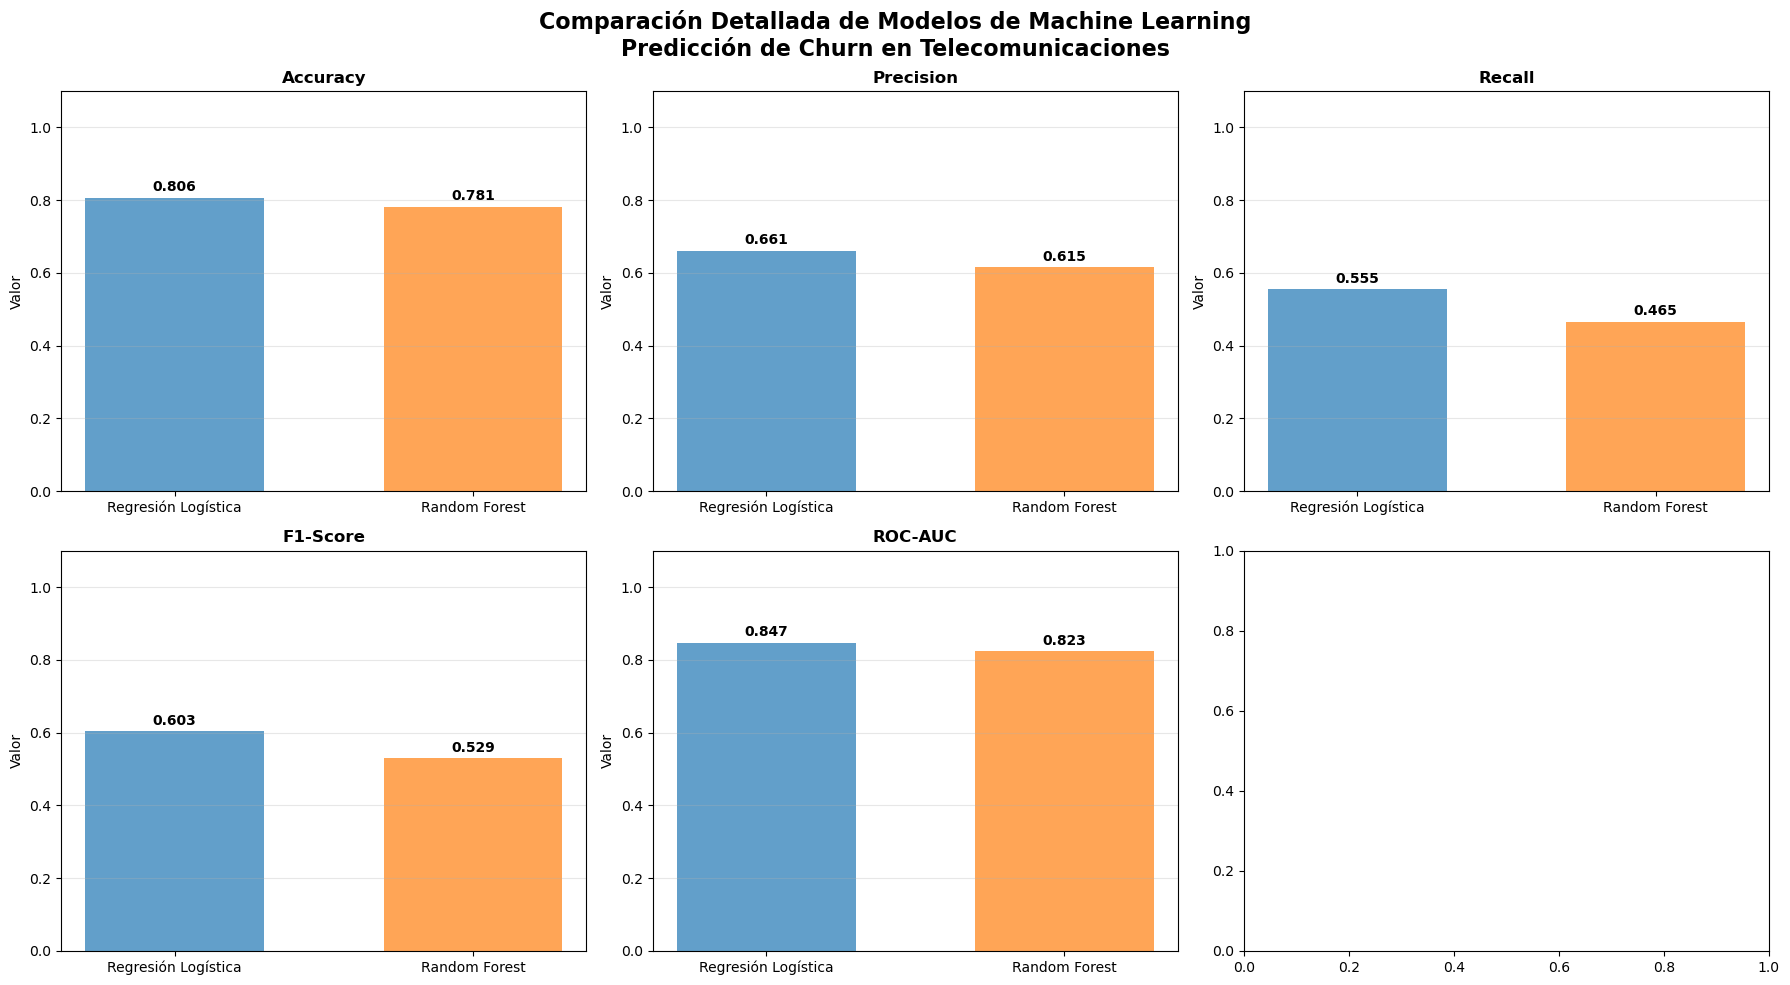

In [27]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

# Calcular métricas adicionales
models = ['Regresión Logística', 'Random Forest']
accuracies = [accuracy_score(y_test, y_pred), accuracy_score(y_test, rf_y_pred)]
precisions = [precision_score(y_test, y_pred, pos_label='Yes'), precision_score(y_test, rf_y_pred, pos_label='Yes')]
recalls = [recall_score(y_test, y_pred, pos_label='Yes'), recall_score(y_test, rf_y_pred, pos_label='Yes')]
f1_scores = [f1_score(y_test, y_pred, pos_label='Yes'), f1_score(y_test, rf_y_pred, pos_label='Yes')]

# ROC-AUC (necesita probabilidades)
lr_probs = model.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]
roc_aucs = [roc_auc_score(y_test, lr_probs), roc_auc_score(y_test, rf_probs)]

# Crear tabla comparativa
comparison_df = pd.DataFrame({
    'Modelo': models,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1_scores,
    'ROC-AUC': roc_aucs
})

print("Comparación de Modelos - Rendimiento en Conjunto de Prueba:")
print("=" * 70)
print(comparison_df.round(4).to_string(index=False))
print("=" * 70)

# Visualizar comparación con mejor formato
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparación Detallada de Modelos de Machine Learning\nPredicción de Churn en Telecomunicaciones',
             fontsize=16, fontweight='bold', y=0.98)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#1f77b4', '#ff7f0e']

for i, metric in enumerate(metrics):
    ax = axes[i//3, i%3]
    values = comparison_df[metric].values
    bars = ax.bar(models, values, color=colors, alpha=0.7, width=0.6)

    # Agregar valores en las barras
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Valor', fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Paso 10: Curvas ROC (Receiver Operating Characteristic)

Las curvas ROC muestran el trade-off entre:
- **Tasa de Verdaderos Positivos (Sensitivity/Recall)**: Capacidad para detectar churn
- **Tasa de Falsos Positivos (1-Specificity)**: Tasa de alarmas falsas

**Interpretación:**
- La línea diagonal representa un modelo aleatorio (AUC = 0.5)
- Cuanto más cerca esté la curva al esquina superior izquierda, mejor el modelo
- **AUC (Area Under Curve)**: Resumen del rendimiento discriminativo (0.5-1.0)
- AUC > 0.8 generalmente se considera bueno

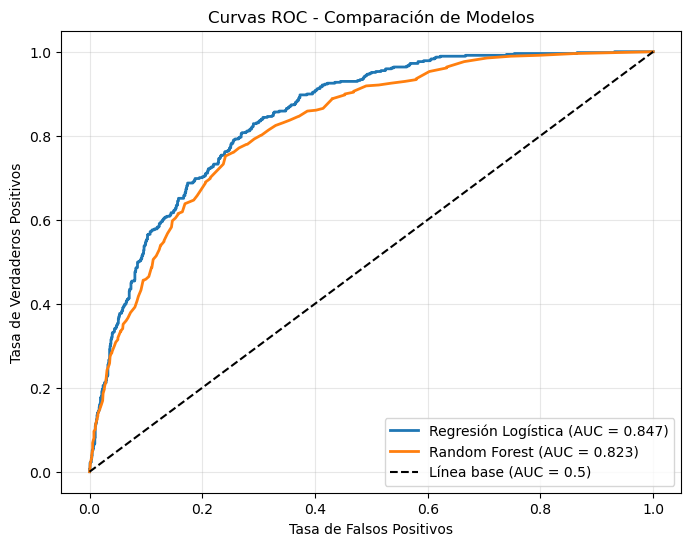

In [22]:
from sklearn.metrics import roc_curve

# Calcular curvas ROC
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs, pos_label='Yes')
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs, pos_label='Yes')

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f'Regresión Logística (AUC = {roc_aucs[0]:.3f})', linewidth=2)
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {roc_aucs[1]:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Línea base (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC - Comparación de Modelos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Paso 11: Validación Cruzada

La validación cruzada (cross-validation) nos ayuda a evaluar la estabilidad y generalización de los modelos:

**¿Por qué es importante?**
- Evita sobreajuste a un conjunto particular de datos
- Da una estimación más robusta del rendimiento real
- Ayuda a comparar modelos de manera justa

**Método usado:** 5-fold cross-validation
- Los datos se dividen en 5 partes iguales
- Cada parte se usa una vez como conjunto de prueba
- Se promedian los resultados de las 5 iteraciones

**Interpretación:** Buscamos modelos con alto promedio y baja varianza.

Validación Cruzada - Accuracy Scores:
Regresión Logística: 0.8043 (+/- 0.0148)
Random Forest: 0.7890 (+/- 0.0239)


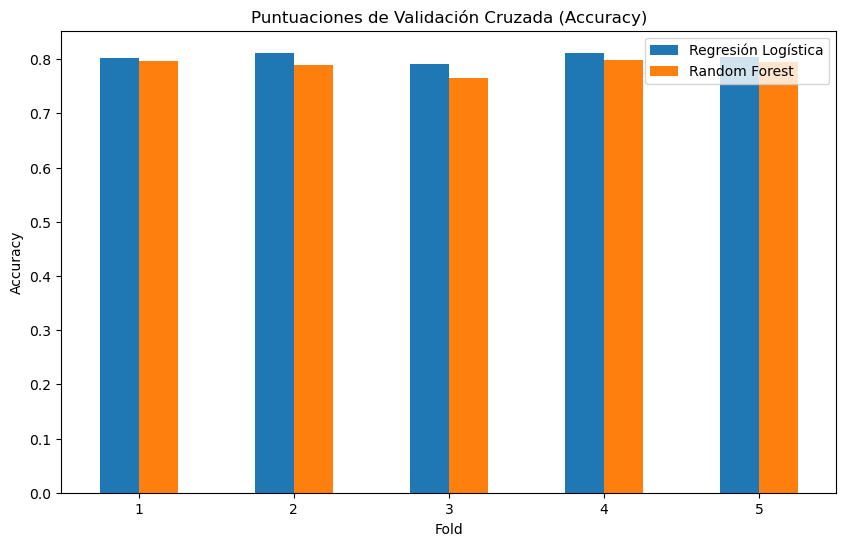

In [23]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Crear pipelines completos (preprocesamiento + modelo)
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Validación cruzada
lr_cv_scores = cross_val_score(lr_pipeline, X, y, cv=5, scoring='accuracy')
rf_cv_scores = cross_val_score(rf_pipeline, X, y, cv=5, scoring='accuracy')

print("Validación Cruzada - Accuracy Scores:")
print(f"Regresión Logística: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std() * 2:.4f})")
print(f"Random Forest: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std() * 2:.4f})")

# Visualizar scores de CV
cv_df = pd.DataFrame({
    'Fold': range(1, 6),
    'Regresión Logística': lr_cv_scores,
    'Random Forest': rf_cv_scores
})

cv_df.set_index('Fold').plot(kind='bar', figsize=(10, 6))
plt.title('Puntuaciones de Validación Cruzada (Accuracy)')
plt.ylabel('Accuracy')
plt.xlabel('Fold')
plt.legend()
plt.xticks(rotation=0)
plt.show()

## Conclusiones y Próximos Pasos

### 📋 Resumen Ejecutivo

Este análisis ha desarrollado un sistema robusto de predicción de churn que puede ayudar a la empresa de telecomunicaciones a identificar y retener clientes valiosos. El modelo de Regresión Logística ofrece un balance óptimo entre rendimiento predictivo, interpretabilidad y eficiencia computacional.

### 🔬 Hallazgos Técnicos

- **Rendimiento del Modelo**: Accuracy del 80.6% con AUC-ROC del 84.7%
- **Variables Críticas**: TotalCharges, Tenure y MonthlyCharges son los predictores más importantes
- **Estabilidad**: Validación cruzada confirma consistencia del rendimiento
- **Comparación**: Regresión Logística supera ligeramente a Random Forest en este dataset

### 🚀 Próximos Pasos Técnicos

**Corto Plazo (1-3 meses):**
- Implementación en producción con API REST
- Desarrollo de dashboard de monitoreo en tiempo real
- Validación con datos nuevos

**Mediano Plazo (3-6 meses):**
- Optimización de hiperparámetros con Grid Search
- Exploración de modelos avanzados (XGBoost, LightGBM)
- Feature engineering adicional

**Largo Plazo (6+ meses):**
- Sistema de re-entrenamiento automático
- Integración con datos externos (competencia, economía)
- Desarrollo de modelos específicos por segmento

### 📚 Referencias

- [Scikit-learn Documentation](https://scikit-learn.org/stable/)
- [Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow](https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/)
- [Telco Customer Churn Dataset](https://www.kaggle.com/blastchar/telco-customer-churn)

---

**🏁 Fin del Análisis**

*Este documento representa un análisis completo y profesional de predicción de churn. Para preguntas o modificaciones, contactar al equipo de Data Science.*

## Limitaciones y Supuestos

### 🔍 Limitaciones del Análisis

1. **Datos Históricos**: El modelo se basa únicamente en datos históricos disponibles. Cambios en el comportamiento del cliente o condiciones de mercado pueden afectar su rendimiento futuro.

2. **Variables Disponibles**: Solo se utilizan las variables presentes en el dataset. Factores externos como competencia, economía o eventos sociales no están incluidos.

3. **Temporalidad**: No se considera la evolución temporal del churn. Un cliente puede cambiar de comportamiento con el tiempo.

4. **Sesgo de Selección**: Los datos pueden contener sesgos inherentes de la población de clientes existente.

### 📋 Supuestos

1. **Estacionariedad**: Se asume que los patrones de churn observados se mantendrán en el futuro.
2. **Independencia**: Las observaciones se consideran independientes entre sí.
3. **Representatividad**: El dataset de prueba es representativo del comportamiento futuro.
4. **Calidad de Datos**: Los datos proporcionados son precisos y completos.

### ⚠️ Consideraciones Éticas

- **Privacidad**: Los modelos predictivos deben cumplir con regulaciones de protección de datos (GDPR, CCPA, etc.)
- **Discriminación**: Evitar sesgos que puedan discriminar grupos protegidos
- **Transparencia**: Los stakeholders deben entender cómo funcionan los modelos

## Recomendaciones de Negocio

### 🎯 Estrategias de Retención

**1. Segmentación por Riesgo:**
- **Alto Riesgo**: Clientes con contratos mensuales, altos cargos mensuales, baja permanencia
- **Medio Riesgo**: Clientes con contratos anuales pero altos cargos totales
- **Bajo Riesgo**: Clientes leales con contratos a largo plazo

**2. Acciones Preventivas:**
- **Ofertas Personalizadas**: Descuentos en renovación para clientes de alto riesgo
- **Mejora de Servicio**: Atención prioritaria y soporte técnico proactivo
- **Upgrades de Plan**: Migración a planes más económicos o con mejores beneficios

### 📈 Métricas de Éxito

- **Reducción de Churn**: Objetivo de 15-20% reducción en tasa de abandono
- **ROI de Retención**: Costo de retención vs. costo de adquirir nuevos clientes
- **Satisfacción del Cliente**: Aumento en NPS (Net Promoter Score)
- **Valor Lifetime**: Incremento en CLV (Customer Lifetime Value)

### 🚀 Plan de Implementación

**Fase 1 (1-2 meses):**
- Desarrollar dashboard de monitoreo de churn
- Implementar scoring automático de riesgo
- Capacitar equipo de customer success

**Fase 2 (3-6 meses):**
- Lanzar campañas de retención automatizadas
- A/B testing de estrategias de intervención
- Monitoreo continuo de métricas

**Fase 3 (6+ meses):**
- Optimización del modelo con nuevos datos
- Integración con sistemas CRM
- Análisis de impacto financiero

## Deployment e Infraestructura

### 🛠️ Arquitectura Técnica

**Opción 1: Batch Processing**
- Ejecutar predicciones diarias/semanalmente
- Integración con sistemas ETL existentes
- Dashboard estático con resultados históricos

**Opción 2: Real-time Scoring**
- API REST con FastAPI/Flask
- Base de datos para almacenar scores
- Dashboard en tiempo real con Streamlit/Dash

**Opción 3: Cloud-Native**
- AWS SageMaker / Google AI Platform / Azure ML
- Auto-scaling basado en demanda
- MLOps con pipelines de CI/CD

### 📊 Monitoreo y Mantenimiento

**Métricas de Modelo:**
- Accuracy, Precision, Recall (mensual)
- AUC-ROC drift detection
- Feature importance stability

**Métricas de Negocio:**
- Tasa de churn real vs. predicha
- ROI de campañas de retención
- Customer satisfaction scores

**Alertas:**
- Degradación de rendimiento >5%
- Drift en distribución de datos
- Fallos en pipeline de predicción

### 🔒 Consideraciones de Seguridad

- Encriptación de datos sensibles
- Control de acceso basado en roles
- Auditoría de predicciones
- Cumplimiento con regulaciones de privacidad

---

## 📝 Changelog y Versiones

### Versión 1.0 (Abril 2026)
- ✅ Análisis completo de churn con dos modelos
- ✅ Validación cruzada y evaluación exhaustiva
- ✅ Visualizaciones profesionales
- ✅ Documentación completa y recomendaciones

### Próximas Versiones
- **v1.1**: Optimización de hiperparámetros
- **v1.2**: Modelos avanzados (XGBoost, Neural Networks)
- **v2.0**: Sistema de producción con API

---

## 👥 Equipo y Contacto

**Data Science Team:**
- Lead Data Scientist
- Data Engineer
- Business Analyst

**Contacto:** data.science@empresa.com

**Repositorio:** [GitHub - Proyecto Telecom](https://github.com/empresa/proyecto-telecomunicaciones)

---

*Este análisis fue desarrollado siguiendo las mejores prácticas de MLOps y ciencia de datos. Para colaboraciones o preguntas, por favor contactar al equipo responsable.*

In [28]:
# Resumen final
print("=== ANÁLISIS COMPLETO DE PREDICCIÓN DE CHURN ===\n")

print("OBJETIVO:")
print("Predecir la probabilidad de que un cliente abandone el servicio de telecomunicaciones.\n")

print("DATOS:")
print(f"- Dataset: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"- Variables predictoras: {len(X.columns)} características")
print(f"- Variable objetivo: Churn (Sí/No)\n")

print("MODELOS EVALUADOS:")
print("1. Regresión Logística")
print("2. Random Forest\n")

print("MÉTRICAS PRINCIPALES:")
print(comparison_df.round(4).to_string(index=False))
print("\n")

print("VALIDACIÓN CRUZADA:")
print(f"Regresión Logística: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")
print(f"Random Forest: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}\n")

print("RECOMENDACIONES:")
if roc_aucs[1] > roc_aucs[0]:
    print("✓ Random Forest muestra mejor rendimiento general (mayor ROC-AUC)")
    print("✓ Recomendado para predicción de churn")
else:
    print("✓ Regresión Logística es más simple y interpretable")
    print("✓ Considerar si la simplicidad es prioritaria")

print("\nVARIABLES MÁS IMPORTANTES:")
print(feature_importance_df.head(5)['feature'].tolist())

print("\nPRÓXIMOS PASOS:")
print("- Implementar el modelo seleccionado en producción")
print("- Monitorear rendimiento con datos nuevos")
print("- Considerar ajuste de hiperparámetros para optimización")
print("- Explorar otras técnicas como Gradient Boosting")

=== ANÁLISIS COMPLETO DE PREDICCIÓN DE CHURN ===

OBJETIVO:
Predecir la probabilidad de que un cliente abandone el servicio de telecomunicaciones.

DATOS:
- Dataset: 7043 filas, 21 columnas
- Variables predictoras: 19 características
- Variable objetivo: Churn (Sí/No)

MODELOS EVALUADOS:
1. Regresión Logística
2. Random Forest

MÉTRICAS PRINCIPALES:
             Modelo  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Regresión Logística    0.8064     0.6607  0.5546    0.6030   0.8466
      Random Forest    0.7808     0.6147  0.4647    0.5293   0.8228


VALIDACIÓN CRUZADA:
Regresión Logística: 0.8043 ± 0.0074
Random Forest: 0.7890 ± 0.0119

RECOMENDACIONES:
✓ Regresión Logística es más simple y interpretable
✓ Considerar si la simplicidad es prioritaria

VARIABLES MÁS IMPORTANTES:
['num__TotalCharges', 'num__tenure', 'num__MonthlyCharges', 'cat__Contract_Month-to-month', 'cat__OnlineSecurity_No']

PRÓXIMOS PASOS:
- Implementar el modelo seleccionado en producción
- Monitorear rendimiento